# Исследовательский анализ данных Online Retail II


In [262]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
DATA_DIR = Path("data")

## 1. Загрузка данных


In [263]:
file_paths = {
    "2009-2010": DATA_DIR / "Year 2009-2010.csv",
    "2010-2011": DATA_DIR / "Year 2010-2011.csv",
}

raw_tables = {
    name: pd.read_csv(path, encoding="cp1252")
    for name, path in file_paths.items()
}

table_overview = pd.DataFrame(
    {
        "rows": {name: len(frame) for name, frame in raw_tables.items()},
        "columns": {name: frame.shape[1] for name, frame in raw_tables.items()},
        "full_duplicates": {name: frame.duplicated().sum() for name, frame in raw_tables.items()},
    }
)

display(table_overview)
display(raw_tables["2009-2010"].head())

,rows,columns,full_duplicates
2009-2010,525461,8,6865
2010-2011,541910,8,5268


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.250,"13,085.000",United Kingdom


In [264]:
print("Схемы совпадают:", raw_tables["2009-2010"].columns.equals(raw_tables["2010-2011"].columns))

schema = pd.DataFrame(
    {
        "2009-2010": raw_tables["2009-2010"].dtypes.astype(str),
        "2010-2011": raw_tables["2010-2011"].dtypes.astype(str),
    }
)
display(schema)

Схемы совпадают: True


,2009-2010,2010-2011
Invoice,str,str
StockCode,str,str
Description,str,str
Quantity,int64,int64
InvoiceDate,str,str
Price,float64,float64
Customer ID,float64,float64
Country,str,str


## 2. Мержим таблицы


In [265]:
def standardize(frame: pd.DataFrame, source: str) -> pd.DataFrame:
    result = frame.copy()
    result.columns = (
        result.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_", regex=False)
    )
    result["invoice_date"] = pd.to_datetime(result.pop("invoicedate"), errors="coerce")
    result["source"] = source
    return result


first = standardize(raw_tables["2009-2010"], "2009-2010")
second = standardize(raw_tables["2010-2011"], "2010-2011")

date_ranges = pd.DataFrame(
    {
        "min_date": [first["invoice_date"].min(), second["invoice_date"].min()],
        "max_date": [first["invoice_date"].max(), second["invoice_date"].max()],
    },
    index=["2009-2010", "2010-2011"],
)
display(date_ranges)

,min_date,max_date
2009-2010,2009-12-01 07:45:00,2010-12-09 20:01:00
2010-2011,2010-12-01 08:26:00,2011-12-09 12:50:00


In [230]:
overlap_start = second["invoice_date"].min()
overlap_end = first["invoice_date"].max()

first_overlap = (
    first[first["invoice_date"].between(overlap_start, overlap_end)]
    .drop(columns="source")
    .reset_index(drop=True)
)
second_overlap = (
    second[second["invoice_date"].between(overlap_start, overlap_end)]
    .drop(columns="source")
    .reset_index(drop=True)
)

overlap_summary = pd.Series(
    {
        "Начало пересечения": overlap_start,
        "Конец пересечения": overlap_end,
        "Строк в первой таблице": len(first_overlap),
        "Строк во второй таблице": len(second_overlap),
        "Уникальных invoice": first_overlap["invoice"].nunique(),
    }
)
display(overlap_summary.to_frame("value"))

,value
Начало пересечения,2010-12-01 08:26:00
Конец пересечения,2010-12-09 20:01:00
Строк в первой таблице,22523
Строк во второй таблице,22523
Уникальных invoice,1088


In [266]:
combined_df = pd.concat(
    [first[first["invoice_date"] < overlap_start], second],
    ignore_index=True,
)

print(f"Строк при простой конкатенации: {len(first) + len(second):,}")
print(f"Строк после устранения пересечения: {len(combined_df):,}")
print(f"Исключено повторно загруженных строк: {len(first) + len(second) - len(combined_df):,}")

Строк при простой конкатенации: 1,067,371
Строк после устранения пересечения: 1,044,848
Исключено повторно загруженных строк: 22,523


## 3. Дубликаты


In [267]:
duplicate_mask = combined_df.duplicated(keep=False)
duplicate_rows = combined_df[duplicate_mask].sort_values(
    ["invoice", "stockcode", "invoice_date"]
)

print(f"Полных дубликатов: {combined_df.duplicated().sum():,}")
print(f"Доля полных дубликатов: {combined_df.duplicated().mean():.2%}")
display(duplicate_rows.head(12))

Полных дубликатов: 11,812
Доля полных дубликатов: 1.13%


,invoice,stockcode,description,quantity,price,customer_id,country,invoice_date,source
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,1.950,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,1.950,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
394,489517,21912,VINTAGE SNAKES & LADDERS,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,3.750,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,0.850,"16,329.000",United Kingdom,2009-12-01 11:34:00,2009-2010


In [268]:
rows_before_deduplication = len(combined_df)
global_df = combined_df.drop_duplicates().reset_index(drop=True)

print(f"До удаления: {rows_before_deduplication:,}")
print(f"После удаления: {len(global_df):,}")
print(f"Удалено: {rows_before_deduplication - len(global_df):,}")

До удаления: 1,044,848
После удаления: 1,033,036
Удалено: 11,812


## 4. Пропущенные значения


In [269]:
missing_before = pd.DataFrame(
    {
        "missing": global_df.isna().sum(),
        "missing_pct": global_df.isna().mean() * 100,
    }
).sort_values("missing_pct", ascending=False)

display(missing_before)

,missing,missing_pct
customer_id,235151,22.763
description,4275,0.414
invoice,0,0.000
stockcode,0,0.000
quantity,0,0.000
price,0,0.000
country,0,0.000
invoice_date,0,0.000
source,0,0.000


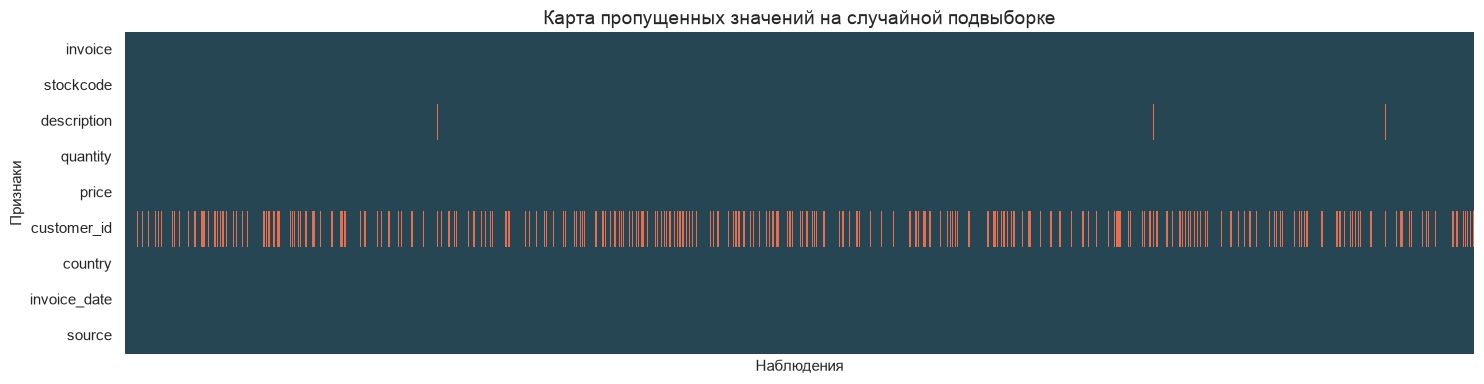

In [270]:
missing_sample = global_df.sample(
    min(1_500, len(global_df)),
    random_state=RANDOM_STATE,
).isna().T

plt.figure(figsize=(15, 4))
sns.heatmap(
    missing_sample,
    cmap=["#264653", "#E76F51"],
    cbar=False,
    yticklabels=True,
    xticklabels=False,
)
plt.title("Карта пропущенных значений на случайной подвыборке")
plt.xlabel("Наблюдения")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

In [236]:
global_df["customer_id_missing"] = global_df["customer_id"].isna()

description_lookup = (
    global_df.dropna(subset=["description"])
             .groupby("stockcode")["description"]
             .agg(lambda values: values.mode().iat[0])
)

missing_description = global_df["description"].isna()
global_df.loc[missing_description, "description"] = (
    global_df.loc[missing_description, "stockcode"].map(description_lookup)
)
global_df["description"] = global_df["description"].fillna("Unknown")

global_df["invoice"] = global_df["invoice"].astype("string")
global_df["stockcode"] = global_df["stockcode"].astype("string")
global_df["description"] = global_df["description"].astype("string")
global_df["customer_id"] = global_df["customer_id"].astype("Int64").astype("string")
global_df["country"] = global_df["country"].astype("category")

missing_after = pd.DataFrame(
    {
        "missing": global_df.isna().sum(),
        "missing_pct": global_df.isna().mean() * 100,
    }
).sort_values("missing_pct", ascending=False)

display(missing_after)

,missing,missing_pct
customer_id,235151,22.763
invoice,0,0.000
stockcode,0,0.000
description,0,0.000
quantity,0,0.000
price,0,0.000
country,0,0.000
invoice_date,0,0.000
source,0,0.000
customer_id_missing,0,0.000


## 5. Преобразуем данные 


In [271]:
global_df["line_total"] = global_df["quantity"] * global_df["price"]
global_df["year"] = global_df["invoice_date"].dt.year
global_df["month"] = global_df["invoice_date"].dt.month
global_df["year_month"] = global_df["invoice_date"].dt.to_period("M").dt.to_timestamp()
global_df["weekday"] = global_df["invoice_date"].dt.day_name()
global_df["hour"] = global_df["invoice_date"].dt.hour
global_df["invoice_prefix_c"] = global_df["invoice"].str.upper().str.startswith("C", na=False)

global_df["quantity_sign"] = np.select(
    [global_df["quantity"] < 0, global_df["quantity"] == 0],
    ["negative", "zero"],
    default="positive",
)

display(global_df.dtypes.to_frame("dtype"))

,dtype
invoice,str
stockcode,str
description,str
quantity,int64
price,float64
customer_id,float64
country,str
invoice_date,datetime64[us]
source,str
line_total,float64


In [238]:
numeric_summary = global_df[["quantity", "price", "line_total"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_summary)

sign_summary = pd.Series(
    {
        "quantity < 0": (global_df["quantity"] < 0).sum(),
        "quantity = 0": (global_df["quantity"] == 0).sum(),
        "price < 0": (global_df["price"] < 0).sum(),
        "price = 0": (global_df["price"] == 0).sum(),
        "invoice начинается с C": global_df["invoice_prefix_c"].sum(),
    }
)
display(sign_summary.to_frame("rows"))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
quantity,"1,033,036.000",10.077,175.198,"-80,995.000",-3.000,1.000,1.000,3.000,10.000,30.000,108.000,"80,995.000"
price,"1,033,036.000",4.614,122.398,"-53,594.360",0.210,0.420,1.250,2.100,4.150,9.950,18.000,"38,970.000"
line_total,"1,033,036.000",18.253,295.687,"-168,469.600",-7.950,0.850,3.750,9.920,17.700,59.800,182.880,"168,469.600"


,rows
quantity < 0,22496
quantity = 0,0
price < 0,5
price = 0,6014
invoice начинается с C,19104


In [272]:
positive_rows = global_df[
    global_df["invoice"].str.fullmatch(r"\d+", na=False)
    & (global_df["quantity"] > 0)
    & (global_df["price"] > 0)
].copy()

print(f"Все строки: {len(global_df):,}")
print(f"Положительная аналитическая подвыборка: {len(positive_rows):,} ({len(positive_rows) / len(global_df):.1%})")

Все строки: 1,033,036
Положительная аналитическая подвыборка: 1,007,912 (97.6%)


## 6. Графики числовых признаков


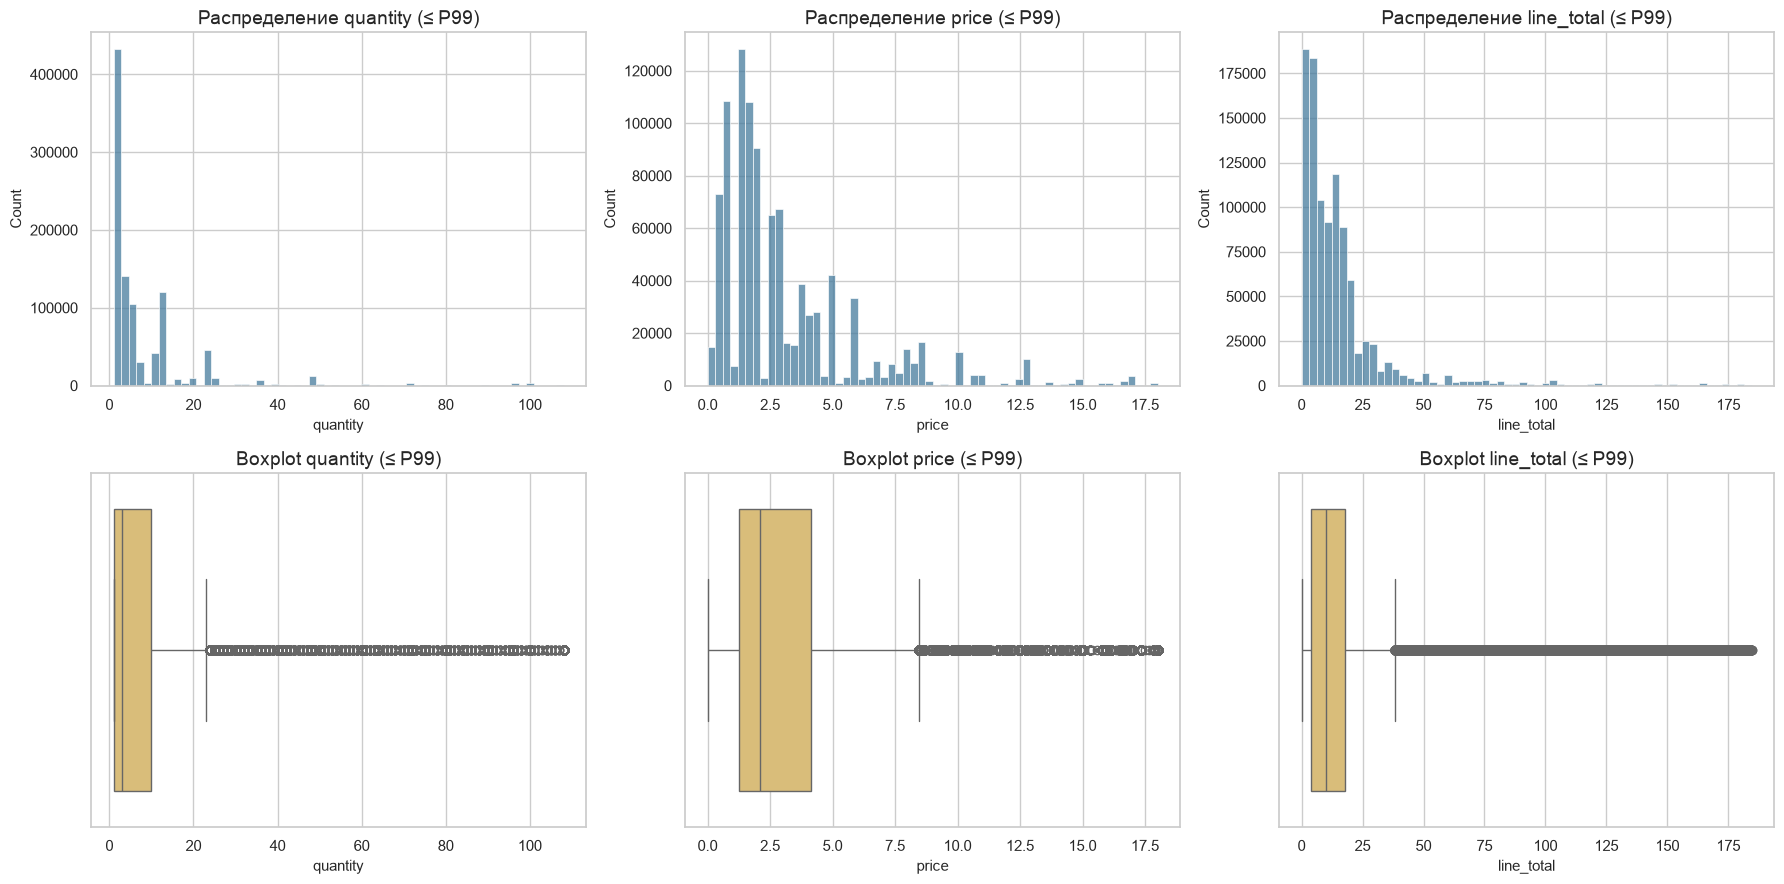

In [292]:
plot_limits = {
    column: positive_rows[column].quantile(0.99)
    for column in ["quantity", "price", "line_total"]
}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for index, column in enumerate(["quantity", "price", "line_total"]):
    subset = positive_rows.loc[positive_rows[column] <= plot_limits[column], column]
    sns.histplot(subset, bins=60, ax=axes[0, index], color="#457B9D")
    axes[0, index].set_title(f"Распределение {column} (≤ P99)")
    sns.boxplot(x=subset, ax=axes[1, index], color="#E9C46A")
    axes[1, index].set_title(f"Boxplot {column} (≤ P99)")

plt.tight_layout()
plt.show()

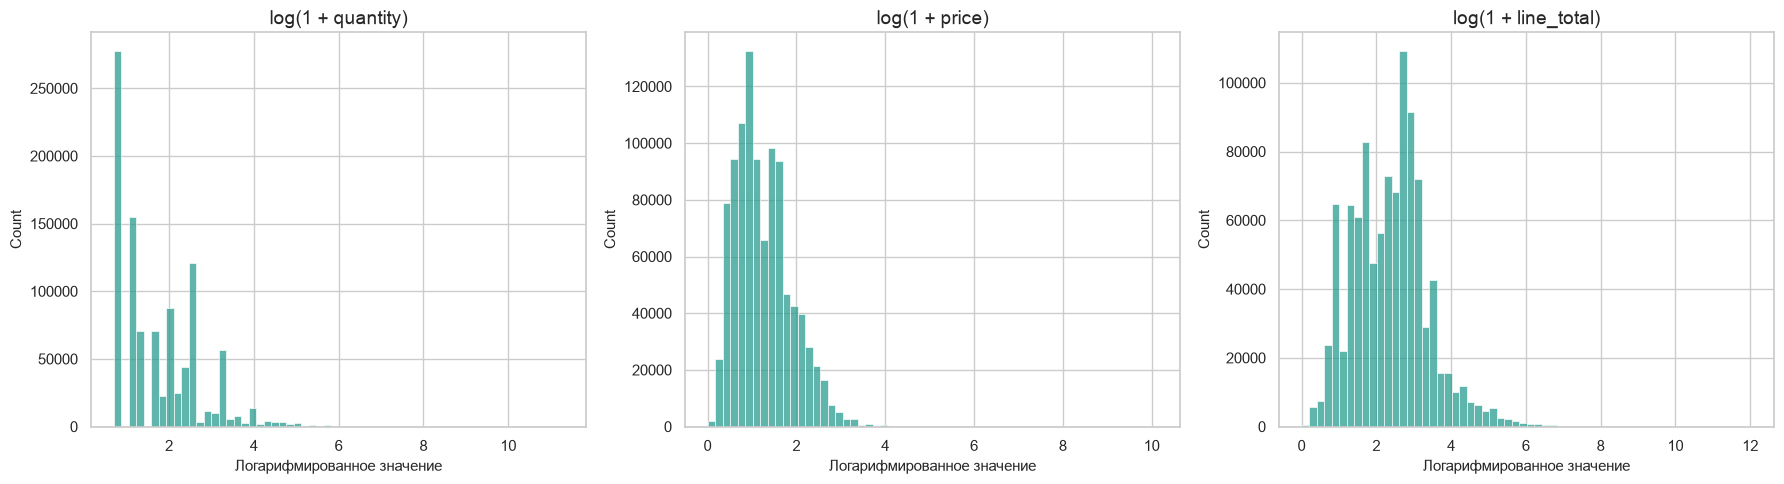

In [274]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, column in zip(axes, ["quantity", "price", "line_total"]):
    sns.histplot(np.log1p(positive_rows[column]), bins=60, ax=axis, color="#2A9D8F")
    axis.set_title(f"log(1 + {column})")
    axis.set_xlabel("Логарифмированное значение")

plt.tight_layout()
plt.show()

## 7. Категориальные признаки

In [275]:
categorical_summary = pd.DataFrame(
    {
        "unique": global_df[["invoice", "stockcode", "description", "customer_id", "country"]].nunique(),
        "missing": global_df[["invoice", "stockcode", "description", "customer_id", "country"]].isna().sum(),
    }
)
display(categorical_summary)

,unique,missing
invoice,53628,0
stockcode,5305,0
description,5698,4275
customer_id,5942,235151
country,43,0


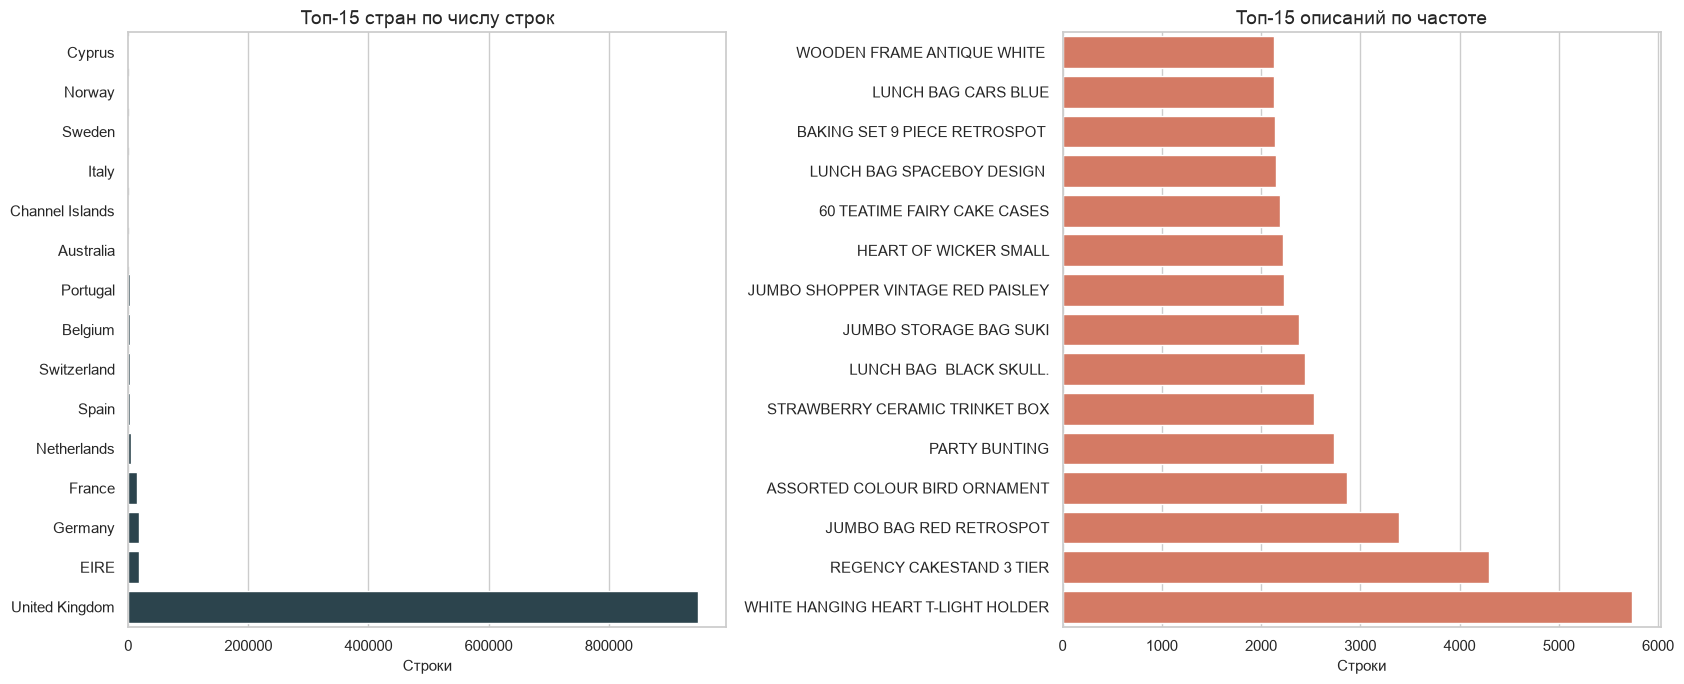

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

top_countries = global_df["country"].value_counts().head(15).sort_values()
top_descriptions = global_df["description"].value_counts().head(15).sort_values()

sns.barplot(x=top_countries.values, y=top_countries.index.astype(str), ax=axes[0], color="#264653")
axes[0].set(title="Топ-15 стран по числу строк", xlabel="Строки", ylabel="")

sns.barplot(x=top_descriptions.values, y=top_descriptions.index, ax=axes[1], color="#E76F51")
axes[1].set(title="Топ-15 описаний по частоте", xlabel="Строки", ylabel="")

plt.tight_layout()
plt.show()

## 8. Анализ по времени


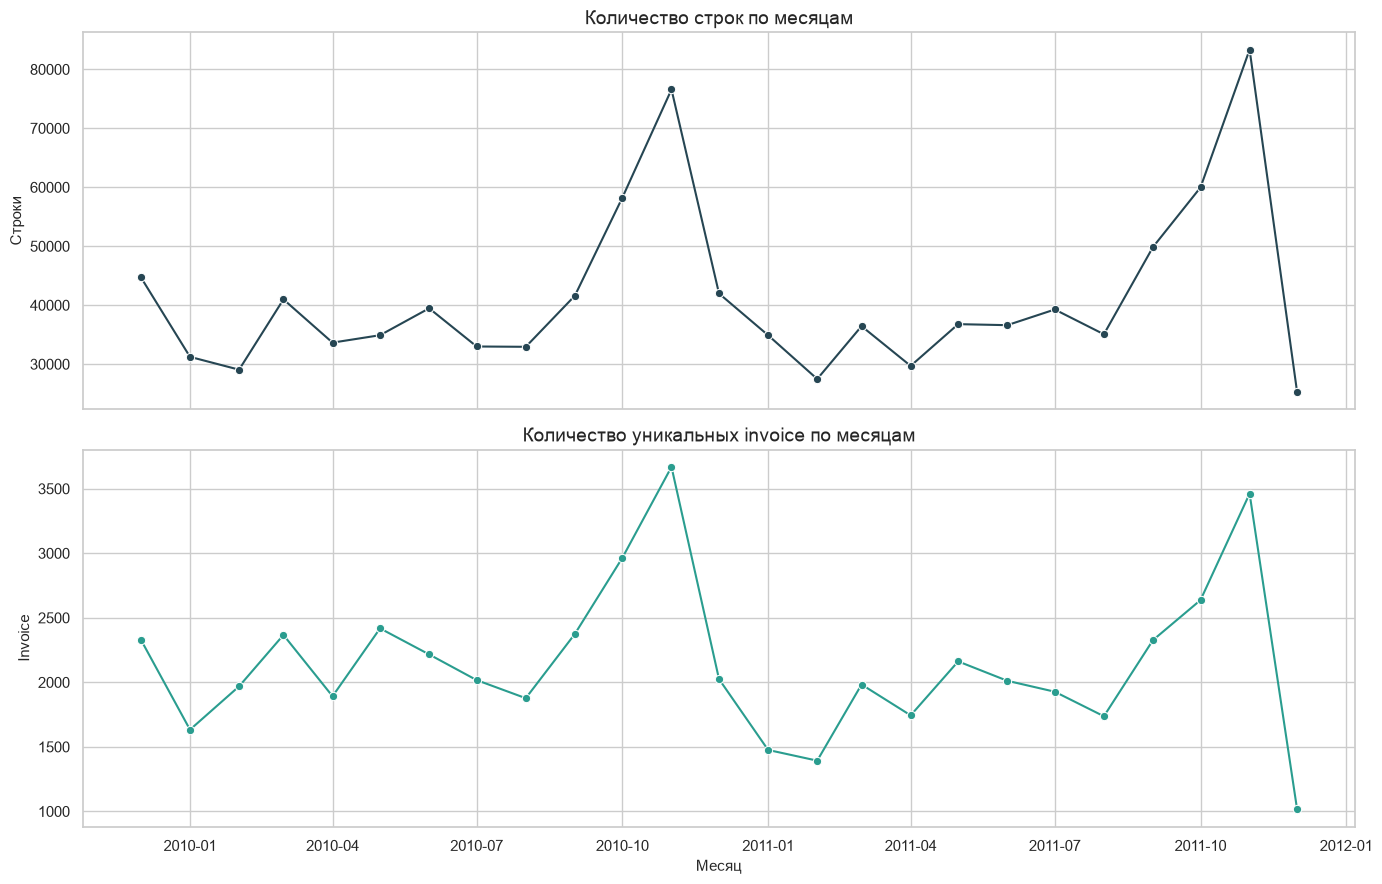

In [276]:
monthly_activity = (
    global_df.groupby("year_month", as_index=False)
             .agg(
                 rows=("invoice", "size"),
                 invoices=("invoice", "nunique"),
                 stockcodes=("stockcode", "nunique"),
             )
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
sns.lineplot(data=monthly_activity, x="year_month", y="rows", marker="o", ax=axes[0], color="#264653")
axes[0].set(title="Количество строк по месяцам", xlabel="", ylabel="Строки")

sns.lineplot(data=monthly_activity, x="year_month", y="invoices", marker="o", ax=axes[1], color="#2A9D8F")
axes[1].set(title="Количество уникальных invoice по месяцам", xlabel="Месяц", ylabel="Invoice")

plt.tight_layout()
plt.show()

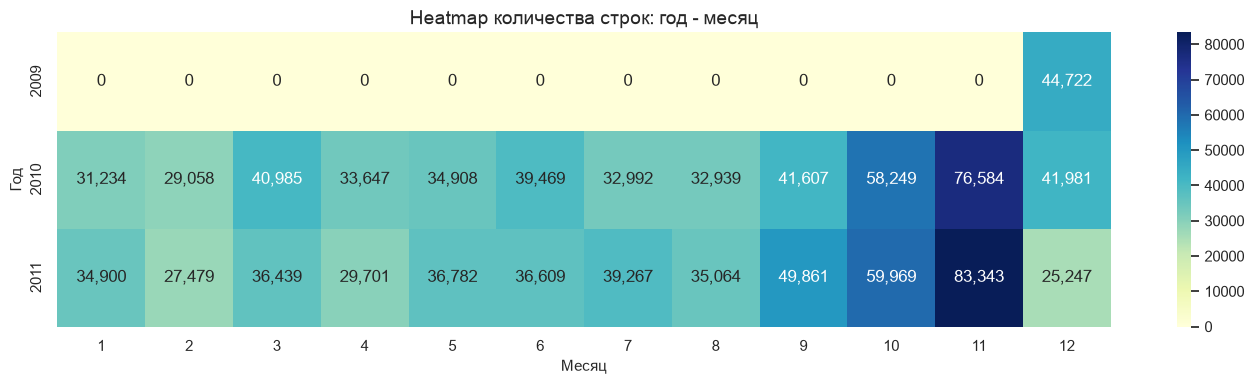

In [293]:
calendar_counts = (
    global_df.groupby(["year", "month"])
             .size()
             .unstack(fill_value=0)
)

plt.figure(figsize=(14, 4))
sns.heatmap(calendar_counts, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Heatmap количества строк: год - месяц")
plt.xlabel("Месяц")
plt.ylabel("Год")
plt.tight_layout()
plt.show()

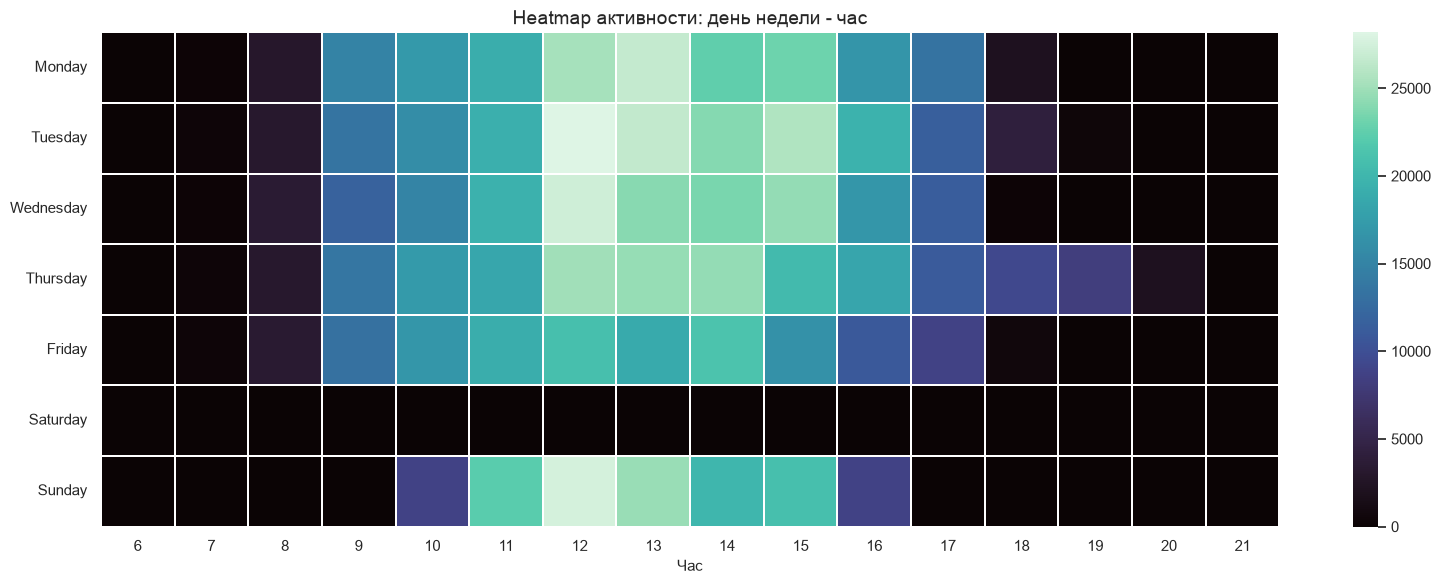

In [277]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_hour = (
    global_df.groupby(["weekday", "hour"])
             .size()
             .unstack(fill_value=0)
             .reindex(weekday_order)
)

plt.figure(figsize=(16, 6))
sns.heatmap(weekday_hour, cmap="mako", linewidths=0.2)
plt.title("Heatmap активности: день недели - час")
plt.xlabel("Час")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Переход к уровню invoice


In [278]:
invoice_df = (
    positive_rows.groupby("invoice", as_index=False)
                 .agg(
                     invoice_total=("line_total", "sum"),
                     total_quantity=("quantity", "sum"),
                     unique_stockcodes=("stockcode", "nunique"),
                     line_count=("stockcode", "size"),
                     country=("country", "first"),
                     customer_id=("customer_id", "first"),
                     invoice_date=("invoice_date", "min"),
                 )
)

invoice_df["year"] = invoice_df["invoice_date"].dt.year
invoice_df["month"] = invoice_df["invoice_date"].dt.month
invoice_df["hour"] = invoice_df["invoice_date"].dt.hour

display(invoice_df.head())
display(invoice_df[["invoice_total", "total_quantity", "unique_stockcodes", "line_count"]].describe().T)

,invoice,invoice_total,total_quantity,unique_stockcodes,line_count,country,customer_id,invoice_date,year,month,hour
0,489434,505.300,166,8,8,United Kingdom,"13,085.000",2009-12-01 07:45:00,2009,12,7
1,489435,145.800,60,4,4,United Kingdom,"13,085.000",2009-12-01 07:46:00,2009,12,7
2,489436,630.330,193,19,19,United Kingdom,"13,078.000",2009-12-01 09:06:00,2009,12,9
3,489437,310.750,145,23,23,United Kingdom,"15,362.000",2009-12-01 09:08:00,2009,12,9
4,489438,"2,286.240",826,17,17,United Kingdom,"18,102.000",2009-12-01 09:24:00,2009,12,9


,count,mean,std,min,25%,50%,75%,max
invoice_total,"40,076.000",510.660,"1,481.410",0.190,149.750,302.220,493.392,"168,469.600"
total_quantity,"40,076.000",279.597,"1,196.165",1.000,64.000,146.000,288.000,"87,167.000"
unique_stockcodes,"40,076.000",24.866,42.179,1.000,6.000,15.000,28.000,"1,110.000"
line_count,"40,076.000",25.150,42.527,1.000,6.000,15.000,29.000,"1,114.000"


## 10. Корреляции


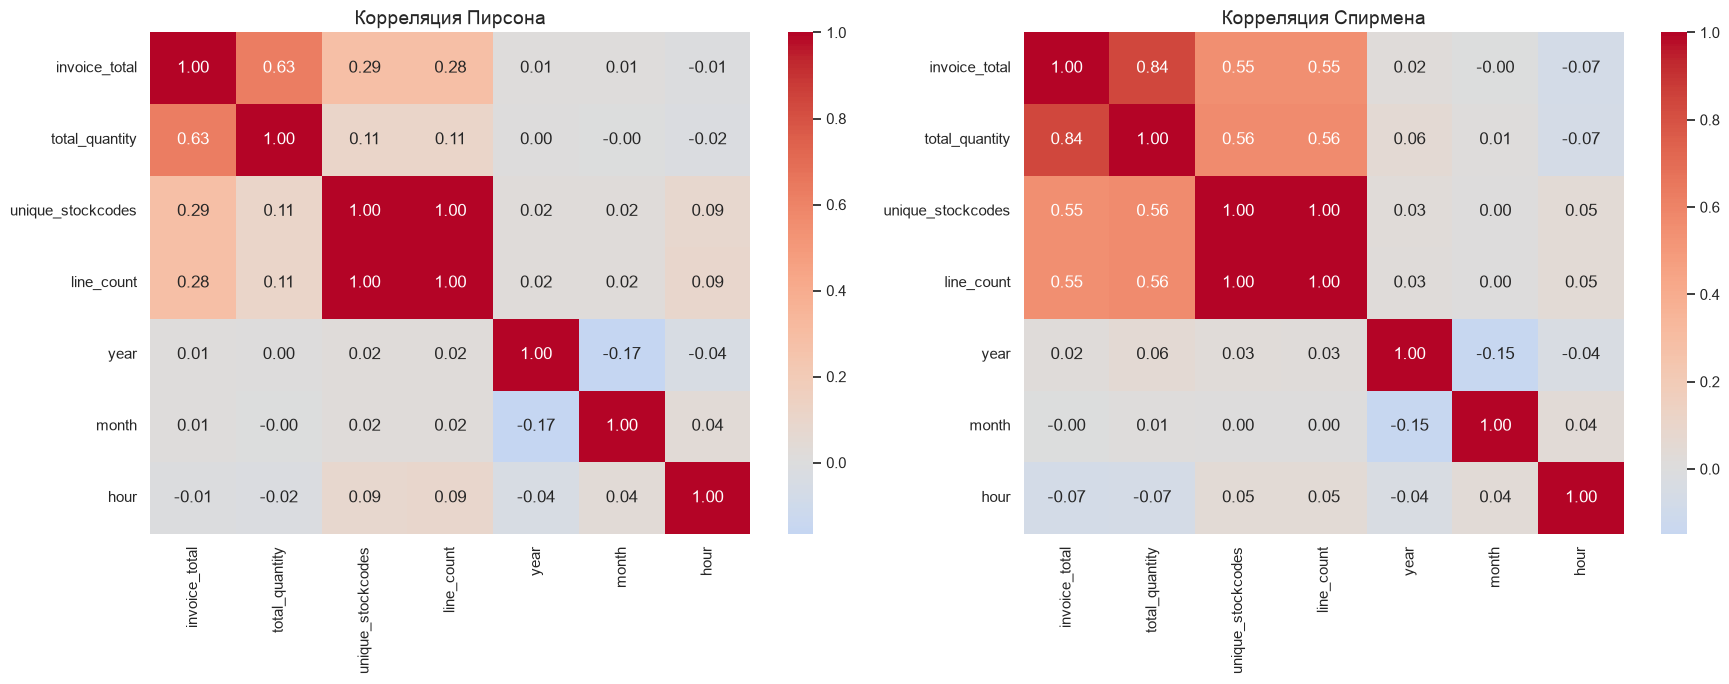

In [279]:
corr_columns = [
    "invoice_total", "total_quantity", "unique_stockcodes",
    "line_count", "year", "month", "hour",
]

pearson_corr = invoice_df[corr_columns].corr(method="pearson")
spearman_corr = invoice_df[corr_columns].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Корреляция Пирсона")

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Корреляция Спирмена")

plt.tight_layout()
plt.show()

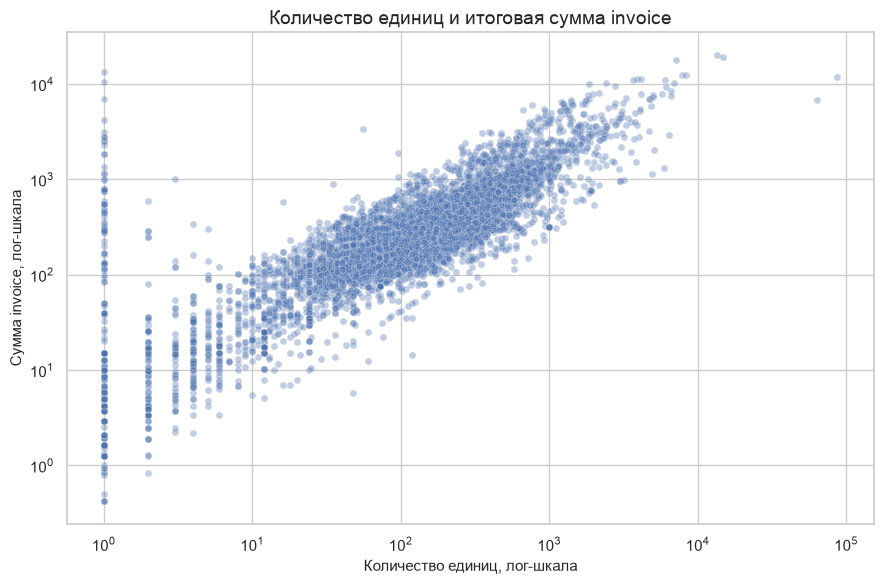

In [280]:
scatter_sample = invoice_df.sample(
    min(8_000, len(invoice_df)),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=scatter_sample,
    x="total_quantity",
    y="invoice_total",
    alpha=0.35,
    s=25,
)
plt.xscale("log")
plt.yscale("log")
plt.title("Количество единиц и итоговая сумма invoice")
plt.xlabel("Количество единиц, лог-шкала")
plt.ylabel("Сумма invoice, лог-шкала")
plt.tight_layout()
plt.show()

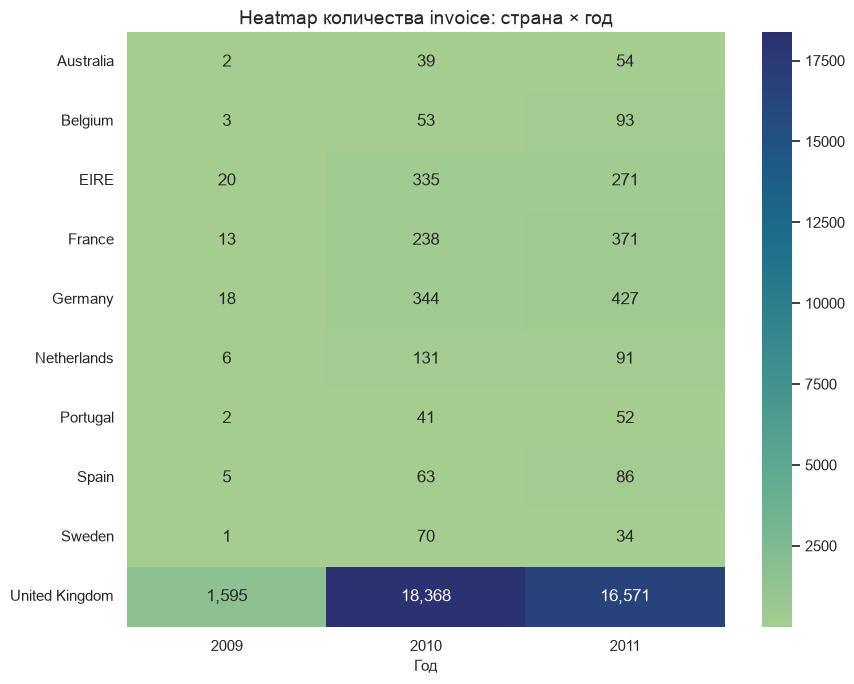

In [250]:
top_country_names = (
    invoice_df["country"].value_counts().head(10).index.astype(str)
)

country_year_matrix = (
    invoice_df[invoice_df["country"].astype(str).isin(top_country_names)]
    .groupby(["country", "year"], observed=True)
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(9, 7))
sns.heatmap(country_year_matrix, annot=True, fmt=",.0f", cmap="crest")
plt.title("Heatmap количества invoice: страна × год")
plt.xlabel("Год")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 11. Анализ выбросов


In [281]:
def iqr_report(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return pd.Series(
        {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outliers": mask.sum(),
            "outlier_pct": mask.mean() * 100,
        }
    )


outlier_report = pd.DataFrame(
    {
        column: iqr_report(invoice_df[column])
        for column in ["invoice_total", "total_quantity", "unique_stockcodes", "line_count"]
    }
).T

display(outlier_report)
display(invoice_df.nlargest(10, "invoice_total"))

,Q1,Q3,IQR,lower_bound,upper_bound,outliers,outlier_pct
invoice_total,149.750,493.392,343.642,-365.714,"1,008.856","3,544.000",8.843
total_quantity,64.000,288.000,224.000,-272.000,624.000,"2,923.000",7.294
unique_stockcodes,6.000,28.000,22.000,-27.000,61.000,"2,716.000",6.777
line_count,6.000,29.000,23.000,-28.500,63.500,"2,680.000",6.687


,invoice,invoice_total,total_quantity,unique_stockcodes,line_count,country,customer_id,invoice_date,year,month,hour
40040,581483,"168,469.600",80995,1,1,United Kingdom,"16,446.000",2011-12-09 09:15:00,2011,12,9
22233,541431,"77,183.600",74215,1,1,United Kingdom,"12,346.000",2011-01-18 10:01:00,2011,1,10
37040,574941,"52,940.940",14149,101,101,United Kingdom,NaN,2011-11-07 17:42:00,2011,11,17
37696,576365,"50,653.910",13956,99,99,United Kingdom,NaN,2011-11-14 17:55:00,2011,11,17
18645,533027,"49,844.990",13387,111,111,United Kingdom,NaN,2010-11-15 16:02:00,2010,11,16
17979,531516,"45,332.970",12410,115,115,United Kingdom,NaN,2010-11-08 16:45:00,2010,11,16
1782,493819,"44,051.600",25018,94,94,EIRE,"14,156.000",2010-01-07 12:34:00,2010,1,12
28810,556444,"38,970.000",60,1,1,United Kingdom,"15,098.000",2011-06-10 15:28:00,2011,6,15
14746,524181,"33,167.800",8172,13,13,United Kingdom,"17,450.000",2010-09-27 16:59:00,2010,9,16
33662,567423,"31,698.160",12572,12,12,United Kingdom,"17,450.000",2011-09-20 11:05:00,2011,9,11


## 12. Статистические методы

В работе используются только два статистических метода:

1. **критерий Манна–Уитни** — для сравнения распределений двух независимых групп;
2. **корреляция Спирмена** — для оценки монотонной связи между двумя числовыми признаками.

Уровень значимости: $0{,}05$. Вместе с `p-value` рассматриваются размеры эффектов, поскольку при большом количестве наблюдений статистически значимым может оказаться практически небольшое различие.

Форма распределения дополнительно изучается описательно: через гистограмму, Q–Q-график и коэффициент асимметрии. Отдельный тест нормальности не применяется.

In [282]:
ALPHA = 0.05
rng = np.random.default_rng(RANDOM_STATE)


def effect_label(value: float) -> str:
    value = abs(value)
    if value < 0.10:
        return "пренебрежимо малый"
    if value < 0.30:
        return "малый"
    if value < 0.50:
        return "средний"
    return "крупный"


def p_text(value: float) -> str:
    return "< 1e-300" if value == 0 else f"{value:.3e}"

### 12.1. Описательная диагностика распределения


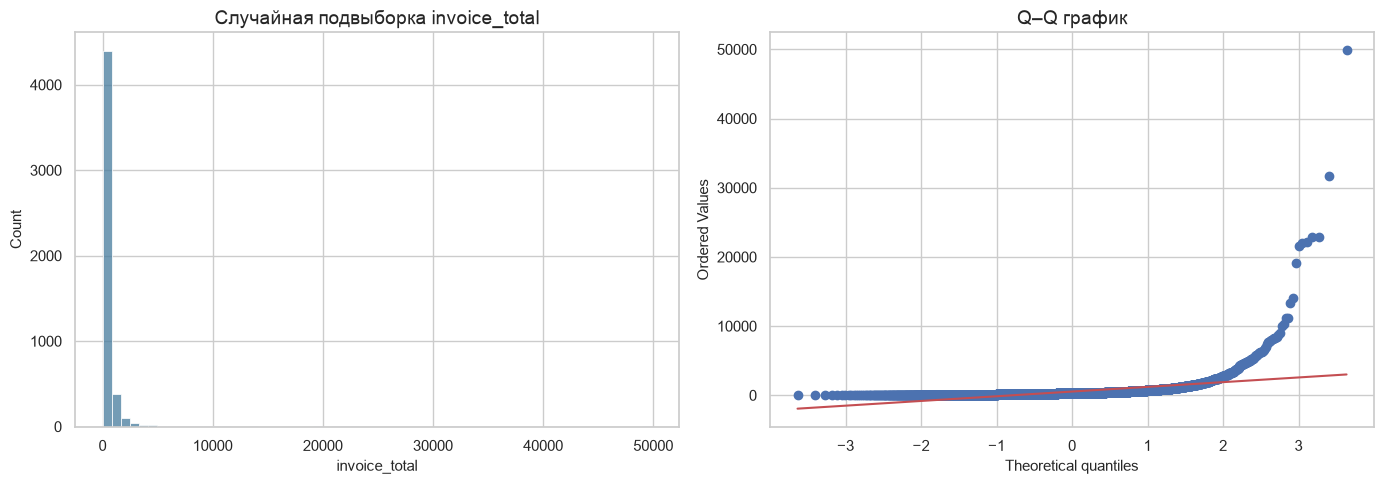

Коэффициент асимметрии: 16.91


In [283]:
distribution_sample = rng.choice(
    invoice_df["invoice_total"].to_numpy(),
    size=min(5_000, len(invoice_df)),
    replace=False,
)
sample_skewness = stats.skew(distribution_sample, bias=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(distribution_sample, bins=60, ax=axes[0], color="#457B9D")
axes[0].set(title="Случайная подвыборка invoice_total", xlabel="invoice_total")

stats.probplot(distribution_sample, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q график")

plt.tight_layout()
plt.show()

print(f"Коэффициент асимметрии: {sample_skewness:.2f}")

### 12.2. Сравнение 2010 и 2011 годов: критерий Манна–Уитни

Сравниваются одинаковые полные периоды — январь–ноябрь.

- **H_0:** распределения `invoice_total` в 2010 и 2011 годах одинаковы;
- **H_1:** распределения различаются.

Используется двусторонний критерий Манна–Уитни. Размер эффекта оценивается рангово-бисериальной корреляцией.

In [290]:
year_comparison = invoice_df[
    invoice_df["year"].isin([2010, 2011])
    & (invoice_df["month"] <= 11)
]

values_2010 = year_comparison.loc[
    year_comparison["year"] == 2010,
    "invoice_total",
].to_numpy()
values_2011 = year_comparison.loc[
    year_comparison["year"] == 2011,
    "invoice_total",
].to_numpy()

mw_stat, mw_p = stats.mannwhitneyu(
    values_2011,
    values_2010,
    alternative="two-sided",
)
rank_biserial = 2 * mw_stat / (len(values_2011) * len(values_2010)) - 1

year_test_summary = pd.DataFrame(
    {
        "year": [2010, 2011],
        "n": [len(values_2010), len(values_2011)],
        "median": [np.median(values_2010), np.median(values_2011)],
        "mean": [values_2010.mean(), values_2011.mean()],
    }
)

display(year_test_summary)
print(f"U = {mw_stat:,.0f}")
print(f"p-value = {mw_p:.3e}")
print(f"Rank-biserial r = {rank_biserial:.3f} ({effect_label(rank_biserial)} эффект)")
print("Решение:", "H_0 отклоняется" if mw_p < ALPHA else "нет оснований отклонить H_0")

,year,n,median,mean
0,2010,18435,301.140,488.834
1,2011,17581,305.170,521.689


U = 165,559,614
p-value = 3.773e-04
Rank-biserial r = 0.022 (пренебрежимо малый эффект)
Решение: H_0 отклоняется


Наблюдения одного клиента могут встречаться в нескольких `invoice`, поэтому строгая независимость может нарушаться. Результат рассматривается как сравнение распределений записей, а не как причинный вывод.

### 12.3. Количество единиц и сумма invoice: корреляция Спирмена

- **H₀:** монотонная связь отсутствует, $\rho=0$;
- **H₁:** существует монотонная связь.

In [288]:
spearman_stat, spearman_p = stats.spearmanr(
    invoice_df["total_quantity"],
    invoice_df["invoice_total"],
)

print(f"Spearman = {spearman_stat:.3f}")
print(f"p-value {p_text(spearman_p)}")
print(f"Размер эффекта: {effect_label(spearman_stat)}")
print("Решение:", "H_0 отклоняется" if spearman_p < ALPHA else "нет оснований отклонить H_0")

Spearman = 0.838
p-value < 1e-300
Размер эффекта: крупный
Решение: H_0 отклоняется


In [287]:
print("ИНТЕРПРЕТАЦИЯ СТАТИСТИЧЕСКИХ МЕТОДОВ")
print("=" * 120)
print(
    f"1. Распределения invoice_total в 2010 и 2011 годах "
    f"{'различаются' if mw_p < ALPHA else 'не различаются'}; "
    f"эффект {effect_label(rank_biserial)} (r={rank_biserial:.3f})."
)
print(
    f"2. Между количеством единиц и суммой invoice наблюдается "
    f"положительная монотонная связь; эффект {effect_label(spearman_stat)} "
    f"(ρ={spearman_stat:.3f})."
)

ИНТЕРПРЕТАЦИЯ СТАТИСТИЧЕСКИХ МЕТОДОВ
1. Распределения invoice_total в 2010 и 2011 годах различаются; эффект пренебрежимо малый (r=0.022).
2. Между количеством единиц и суммой invoice наблюдается положительная монотонная связь; эффект крупный (ρ=0.838).
